# Solid Material Evaluation

Polarimetric analysis of solid materials: plastics, ceramics,
wood, paper, rubber, and composites.

Computes polarization angle and permittivity from the H/V ratio
relative to a copper/metal reference.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import pickle

%load_ext autoreload
%autoreload 2
import sys; sys.path.insert(0, '..')
from polysight.eval import polarimetry as pol
from polysight.eval import permittivity as fresnel

<![CDATA[## Load materials and compute permittivity]]>

In [2]:
materials_dir = '../data/materials/'
pol_config = {'AR': 0.05, 'percentile_range': [30, 70]}

permittivity_list = []

for file_path in sorted(glob.glob(os.path.join(materials_dir, '*_60.pkl'))):
    with open(file_path, 'rb') as f:
        mat = pickle.load(f)

    polarization_angle, angle_refed = pol.calc_polarimetry(
        mat['values'][2], mat['ref_values'][2], config=pol_config)
    pol_val = np.tan(np.deg2rad(polarization_angle))
    eps = fresnel.ratio_to_epsilon(pol_val, mat['incident_angle'])
    eps_complex = fresnel.ratio_to_epsilon(
        pol_val * np.exp(-1j * np.angle(angle_refed)), mat['incident_angle'])

    permittivity_list.append({
        'name': mat['name'] + '_60',
        'permittivity': eps,
        'permittivity_complex': eps_complex,
        'pol_angle': polarization_angle,
        'div_val': angle_refed,
    })

    pol_val_mean = np.tan(np.mean(np.deg2rad(polarization_angle)))
    permt_mean = fresnel.ratio_to_epsilon(pol_val_mean, mat['incident_angle'])
    permittivity_list[-1]['mean_permittivity'] = permt_mean

for file_path in sorted(glob.glob(os.path.join(materials_dir, '*_55.pkl'))):
    with open(file_path, 'rb') as f:
        mat = pickle.load(f)

    polarization_angle, angle_refed = pol.calc_polarimetry(
        mat['values'][2], mat['ref_values'][2], config=pol_config)
    pol_val = np.tan(np.deg2rad(polarization_angle))
    eps = fresnel.ratio_to_epsilon(pol_val, mat['incident_angle'])
    eps_complex = fresnel.ratio_to_epsilon(
        pol_val * np.exp(-1j * np.angle(angle_refed)), mat['incident_angle'])

    permittivity_list.append({
        'name': mat['name'] + '_55',
        'permittivity': eps,
        'permittivity_complex': eps_complex,
        'pol_angle': polarization_angle,
        'div_val': angle_refed,
    })

    pol_val_mean = np.tan(np.mean(np.deg2rad(polarization_angle)))
    permt_mean = fresnel.ratio_to_epsilon(pol_val_mean, mat['incident_angle'])
    permittivity_list[-1]['mean_permittivity'] = permt_mean


<![CDATA[## Permittivity box plots]]>

In [3]:

# Display names for solid materials
show_list = {
    'acrylic_1mm_60': 'acrylic (1mm)',
    'acrylic_3mm_60': 'acrylic (3mm)',
    'PC_1mm_60': 'PC (1mm)',
    'PET_0.5mm_60': 'PET (0.5mm)',
    'PET_1mm_60': 'PET (1mm)',
    'vinyl_60': 'vinyl (0.37mm)',
    'PLA_ender_1mm_60': 'PLA (ender, 1mm)',
    'PLA_hyper_1mm_60': 'PLA (hyper, 1mm)',
    'PVC_60': 'PVC',
    'TPU_1mm_60': 'TPU (1mm)',
    'ceramic_60': 'ceramic',
    'silicone_rubber_60': 'silicone rubber',
    'rubber_60': 'rubber',
    'glass_2mm_60': 'glass (2mm)',
    'PCB_60': 'glass fiber',
    'paper_smooth_60': 'paper (smooth)',
    'cardboard_60': 'cardboard',
    'cardboard_rough_60': 'cardboard (rough)',
    'fabric_60': 'fabric',
    'wood_thin_55': 'wood (thin, smooth)',
    'wood_8_60': 'wood (rough)',
    # 'cork_55': 'cork',
}

# Materials that should use real-only permittivity (no reliable phase info)
real_only = {'cork_55', 'cork_60'}

filtered_permittivity_list = [
    x for key in show_list.keys()
    for x in permittivity_list
    if x['name'] == key
]

material_labels = [show_list[x['name']] for x in filtered_permittivity_list]

print(f'{"Material":<25s} {"ε\'":<10s} {"−jε\"":<10s}')
print('-' * 45)
for x, label in zip(filtered_permittivity_list, material_labels):
    if x['name'] in real_only:
        eps_mean = np.mean(x['permittivity'])
        print(f'{label:<25s} {eps_mean.real:<10.2f} {"N/A":<10s}')
    else:
        eps_mean = np.mean(x['permittivity_complex'])
        print(f'{label:<25s} {eps_mean.real:<10.2f} {abs(eps_mean.imag):<10.2f}')

Material                  ε'         −jε"      
---------------------------------------------
acrylic (1mm)             3.56       0.18      
acrylic (3mm)             4.00       0.40      
PC (1mm)                  4.26       0.21      
PET (0.5mm)               3.78       0.70      
PET (1mm)                 3.83       0.73      
vinyl (0.37mm)            3.65       0.70      
PLA (ender, 1mm)          3.79       0.34      
PLA (hyper, 1mm)          4.21       0.30      
PVC                       4.15       0.81      
TPU (1mm)                 3.91       0.21      
ceramic                   4.75       2.43      
silicone rubber           3.52       0.82      
rubber                    5.06       1.11      
glass (2mm)               7.26       0.85      
glass fiber               4.69       0.70      
paper (smooth)            4.63       0.31      
cardboard                 5.24       0.01      
cardboard (rough)         4.54       0.56      
fabric                    2.21       0.13 

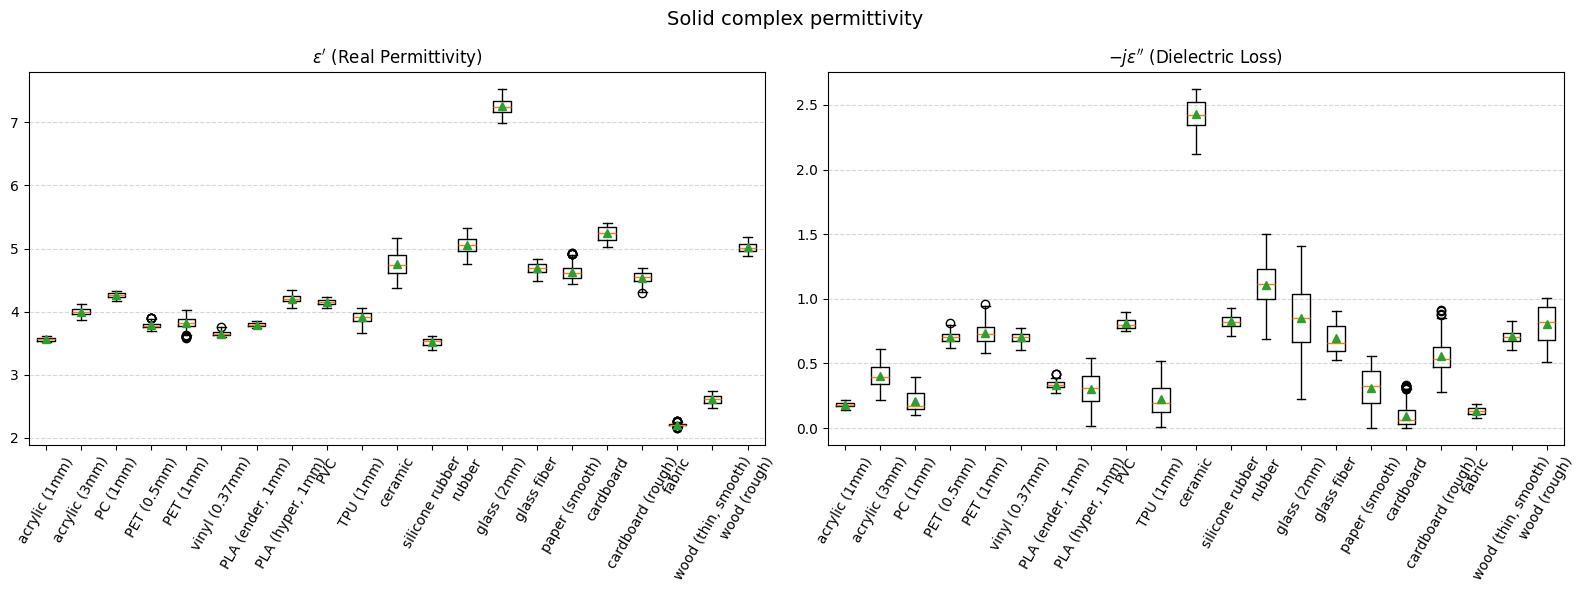

In [4]:
# Box plots: ε' and −jε'' for all solid materials
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

eps_arrays = [x['permittivity_complex'] for x in filtered_permittivity_list]

axes[0].boxplot([x.real.ravel() for x in eps_arrays], showmeans=True)
axes[0].set_title(r"$\epsilon'$ (Real Permittivity)")
axes[0].set_xticks(range(1, len(material_labels) + 1), material_labels)
axes[0].tick_params(axis='x', rotation=60)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

axes[1].boxplot([np.abs(x.imag).ravel() for x in eps_arrays], showmeans=True)
axes[1].set_title(r"$-j\epsilon''$ (Dielectric Loss)")
axes[1].set_xticks(range(1, len(material_labels) + 1), material_labels)
axes[1].tick_params(axis='x', rotation=60)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

fig.suptitle('Solid complex permittivity', fontsize=14)
plt.tight_layout()
plt.show()

## Powder materials

In [5]:
# Powder materials
powder_show_list = {
    'cane_sugar_60':      'Sugar Powder (w/ plastic)',
    'salt_60':            'Salt (w/ plastic)',
    'protein_powder_60':  'Protein Powder (w/ plastic)',
    'milk_powder_60':     'Milk Powder (w/ plastic)',
}

filtered_powder = [
    x for key in powder_show_list.keys()
    for x in permittivity_list
    if x['name'] == key
]

powder_labels = [powder_show_list[x['name']] for x in filtered_powder]

print(f'{"Material":<30s} {"ε\'":<10s} {"−jε\"":<10s}')
print('-' * 50)
for x, label in zip(filtered_powder, powder_labels):
    eps_mean = np.mean(x['permittivity_complex'])
    print(f'{label:<30s} {eps_mean.real:<10.2f} {abs(eps_mean.imag):<10.2f}')

Material                       ε'         −jε"      
--------------------------------------------------
Sugar Powder (w/ plastic)      4.46       0.42      
Salt (w/ plastic)              4.30       0.94      
Protein Powder (w/ plastic)    5.74       0.45      
Milk Powder (w/ plastic)       4.88       0.74      
